<a href="https://colab.research.google.com/github/josedanielisidororeyes/Natural_Language_Processing/blob/main/Ejercicio_de_preprocesamiento_y_normalizaci%C3%B3n_de_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nombre del Alumno: José Daniel Isidoro Reyes
#Matrícula: 261552
#Nombre de la Tarea: Ejercicio de Preprocesamiento y Normalización de Texto

# Carga de Librerías

In [17]:
# Instalación de modelo de lenguaje en español
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 102.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [13]:
import pandas as pd
import re
import unicodedata
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Configuración Inicial
nltk.download('stopwords')
nlp  =  spacy.load('es_core_news_sm')
stop_words =  set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Carga de datos

In [11]:
df  = pd.read_csv('/content/drive/MyDrive/Procesamiento del Lenguaje Natural/tuits_cambio_climatico.csv')
df.head(1)

,tuit
0,Excelente iniciativa de el uso de energías ren...


# Procesamiento y Normalización

In [14]:
tokens_finales  =  []

for tuit in df['tuit']:
    # Transformación a minúsculas y eliminación de acentos
    texto  =  tuit.lower()
    texto  =  ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

    # Eliminación de menciones, hashtags, y emojis
    texto = re.sub(r'http\S+|@\w+|#\w+|[^\w\s]', '', texto)

    # Tokenizacíon y  lematización usando spaCY
    texto = re.sub(r'http\S+|@\w+|#\w+|[^\w\s]', '', texto)

    doc  =  nlp(texto)
    for token in doc:
        if token.text not in stop_words and token.is_alpha and len(token.text) > 2:
            tokens_finales.append(token.lemma_)



# Generación de visualizaciones

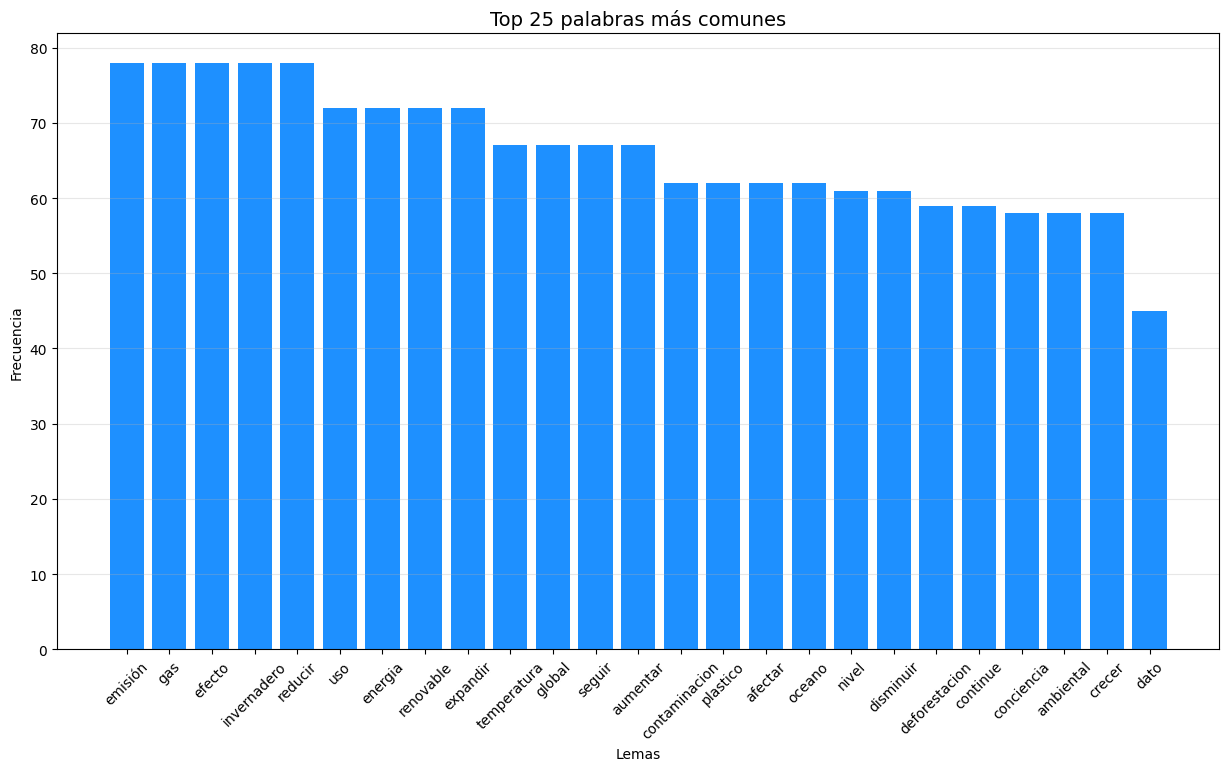

In [15]:
# Conteo de las 25 palabras más comunes
comunes =  Counter(tokens_finales).most_common(25)
palabras, conteos = zip(*comunes)

plt.figure(figsize =  (15, 8))
plt.bar(palabras, conteos, color  =  'dodgerblue')
plt.title('Top 25 palabras más comunes', fontsize = 14)
plt.xlabel('Lemas')
plt.ylabel('Frecuencia')
plt.xticks(rotation  =  45)
plt.grid(axis  =  'y', alpha  = 0.3)
plt.show()


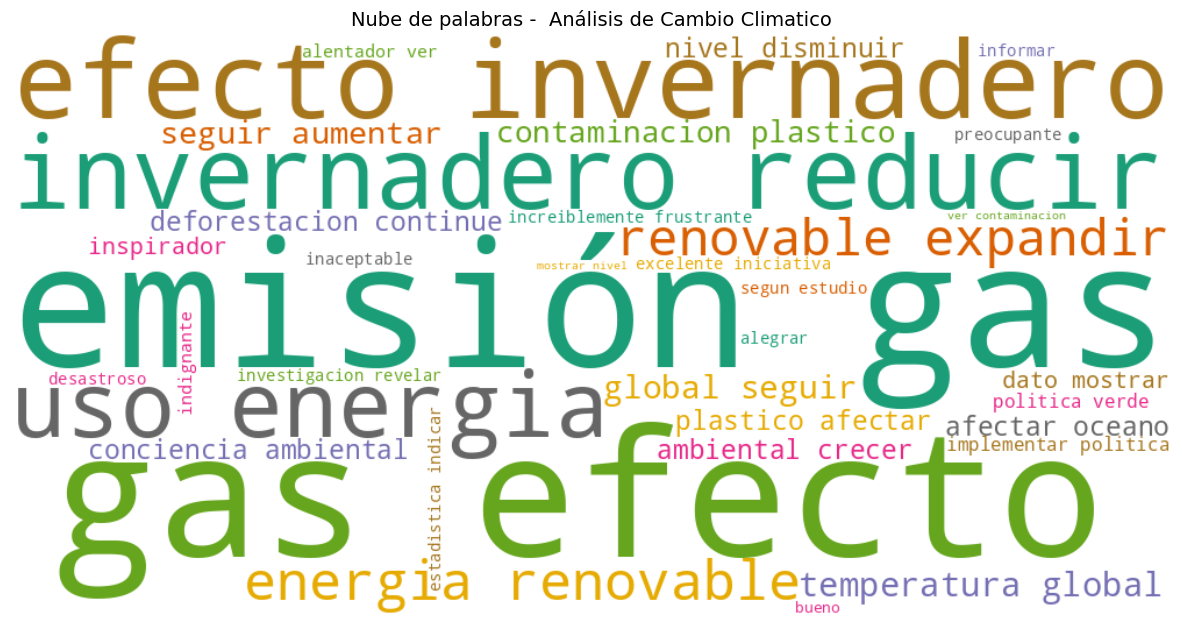

In [16]:
# Nube de palabras
texto_nube  =  " ".join(tokens_finales)
wc =  WordCloud(width = 1000,height =  500, background_color  = 'white', colormap = 'Dark2').generate(texto_nube)
plt.figure(figsize = (15, 8))
plt.imshow(wc, interpolation  = 'bilinear')
plt.axis('off')
plt.title('Nube de palabras -  Análisis de Cambio Climatico', fontsize = 14)
plt.show()